# HOMER: functional estimates and perturbation stability

Functional observations are represented by 12 Fourier coefficients, with concentrated or diffuse covariance spectra. One experiment studies fixed-threshold inference for three contrasts. A separate paired experiment compares point-estimation error under clean data and perturbations concentrated in a few blocks or dispersed across raw observations.

The distinction matters: the adaptive fits in the stability experiment do not inherit the fixed-threshold inference result.


## Choose the results to read

`paper` reads the compact manuscript results. Set `MODE` to `smoke` for a short run or `full` for the manuscript replication counts. Every mode draws figures directly from its selected results inside this notebook, without writing image files or requiring TeX. Fresh numerical results go to `runs/`.

The committed outputs show `paper` mode. After changing `MODE`, run all cells to refresh the tables and figures. Smoke curves check execution and are too imprecise for scientific conclusions.


In [1]:
MODE = "paper"  # "paper", "smoke", or "full"
STUDIES = ['functional']


In [2]:
from pathlib import Path
import subprocess
import sys

import pandas as pd
from IPython.display import Markdown, display

%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("png")
import matplotlib.pyplot as plt
import numpy as np

ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "results").is_dir() and (p / "notebooks").is_dir()),
    None,
)
if ROOT is None:
    raise RuntimeError("Open this notebook from the repository root or notebooks directory.")
if MODE not in {"paper", "smoke", "full"}:
    raise ValueError("MODE must be 'paper', 'smoke', or 'full'.")

sys.path.insert(0, str(ROOT / "code"))
from notebook_plots import (
    scalar_coverage, functional_coverage, functional_stability,
    covariance_heatmaps, wearable_stability,
)

if MODE == "paper":
    RESULTS = ROOT / "results"
    display(Markdown("**Reading the saved manuscript results.** No experiments are rerun."))
else:
    subprocess.run(
        [sys.executable, str(ROOT / "code" / "reproduce.py"), "--mode", MODE,
         "--study", *STUDIES, "--resume"],
        cwd=ROOT, check=True,
    )
    RESULTS = ROOT / "runs" / MODE / "results"
    display(Markdown(f"**Reading {MODE} results** from `runs/{MODE}/results/`."))

pd.set_option("display.max_columns", 12)
pd.set_option("display.precision", 4)

def show_figure(figure):
    display(figure)
    plt.close(figure)


**Reading the saved manuscript results.** No experiments are rerun.

## Inference for functional contrasts

The saved experiment has 12 cells and 500 fits per cell, with three contrast records per fit. These are population-mean coverage summaries with pointwise Monte Carlo intervals.


In [3]:
inference = pd.read_csv(RESULTS / "functional_inference_summary.csv")
display(inference[["spectrum", "distribution", "k", "m", "contrast",
                   "reps", "coverage", "mc_low", "mc_high"]])


,spectrum,distribution,k,m,contrast,reps,coverage,mc_low,mc_high
0,concentrated,exponential,16,256,evening_minus_morning,500,0.918,0.8906,0.9390
1,concentrated,exponential,16,256,interval_average,500,0.934,0.9088,0.9526
2,concentrated,exponential,16,256,smoothed_evaluation,500,0.930,0.9042,0.9492
3,concentrated,exponential,32,1024,evening_minus_morning,500,0.936,0.9110,0.9543
4,concentrated,exponential,32,1024,interval_average,500,0.932,0.9065,0.9509
5,concentrated,exponential,32,1024,smoothed_evaluation,500,0.912,0.8839,0.9338
6,concentrated,exponential,64,4096,evening_minus_morning,500,0.936,0.9110,0.9543
7,concentrated,exponential,64,4096,interval_average,500,0.936,0.9110,0.9543
8,concentrated,exponential,64,4096,smoothed_evaluation,500,0.946,0.9226,0.9626
9,concentrated,gaussian,16,256,evening_minus_morning,500,0.910,0.8817,0.9321


## Paired point-estimation comparisons

Methods share clean observations, affected indices, and perturbation magnitudes. The display names below follow the manuscript; the saved CSV keys remain unchanged. Normal Monte Carlo intervals for Student-t4 MSE comparisons are omitted because a finite fourth moment is not available.


In [4]:
point = pd.read_csv(RESULTS / "functional_point_summary.csv")
DISPLAY_METHOD = {
    "PH(1)": "HOMER(1)", "PH(16)": "HOMER(16)",
    "Adaptive(2)": "Adaptive HOMER", "Canonical(2)": "Canonical adaptive HOMER",
}
point["display_method"] = point["method"].replace(DISPLAY_METHOD)
selected = point.loc[
    point["method"].isin(["Mean", "MOM", "PH(1)", "PH(16)", "Adaptive(2)"]),
    ["spectrum", "distribution", "mechanism", "magnitude", "display_method",
     "reps", "mse", "q95", "mean_realized_block_fraction"],
]
display(selected.reset_index(drop=True))


,spectrum,distribution,mechanism,magnitude,display_method,reps,mse,q95,mean_realized_block_fraction
0,concentrated,gaussian,clean,0.0,Adaptive HOMER,500,0.0005,0.0407,0.000
1,concentrated,gaussian,clean,0.0,MOM,500,0.0006,0.0449,0.000
2,concentrated,gaussian,clean,0.0,Mean,500,0.0005,0.0396,0.000
3,concentrated,gaussian,clean,0.0,HOMER(1),500,0.0005,0.0406,0.000
4,concentrated,gaussian,clean,0.0,HOMER(16),500,0.0005,0.0396,0.000
...,...,...,...,...,...,...,...,...,...
95,diffuse,student_t4,whole_block,100.0,Adaptive HOMER,500,0.0021,0.0570,0.125
96,diffuse,student_t4,whole_block,100.0,MOM,500,0.0009,0.0388,0.125
97,diffuse,student_t4,whole_block,100.0,Mean,500,156.2391,12.5102,0.125
98,diffuse,student_t4,whole_block,100.0,HOMER(1),500,0.0012,0.0444,0.125


In [5]:
# Inference failures are recorded once per contrast, so deduplicate the fits' cells.
checks = inference.drop_duplicates(["spectrum", "distribution", "a", "k", "m"])
display(checks[["solver_failures", "covariance_failures", "certificate_failures"]]
        .sum().rename("total").to_frame())


,total
solver_failures,0
covariance_failures,0
certificate_failures,0


## Functional coverage and stability

The first figure shows the two contrasts used in the main manuscript. The second shows Gaussian efficiency and sensitivity to block and raw-observation contamination. All points and Monte Carlo intervals come from the selected results. The wearable panel is shown in `covariance_wearable.ipynb`.


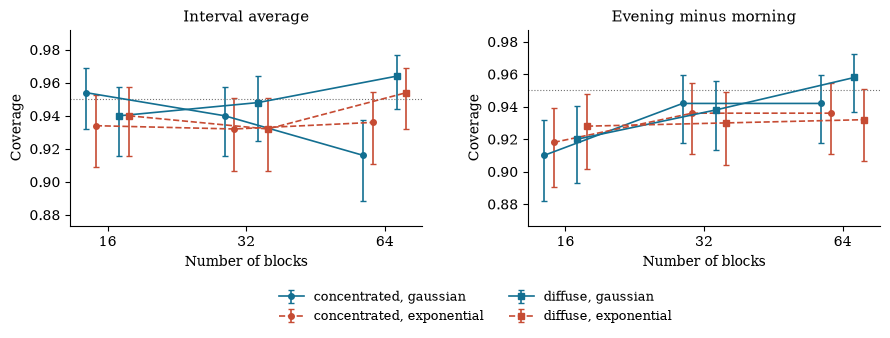

In [6]:
show_figure(functional_coverage(inference))


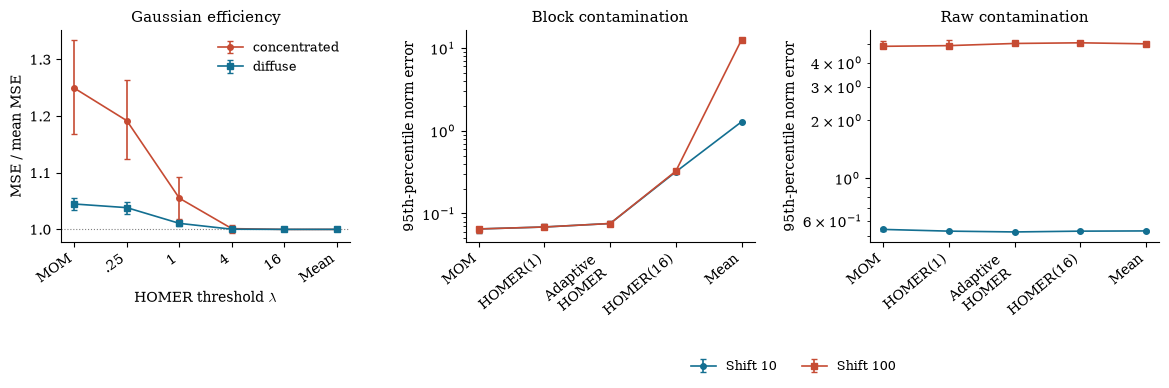

In [7]:
efficiency_concentrated = pd.read_csv(RESULTS / "efficiency_ratio_concentrated.csv")
efficiency_diffuse = pd.read_csv(RESULTS / "efficiency_ratio_diffuse.csv")
show_figure(functional_stability(point, efficiency_concentrated, efficiency_diffuse))


## Interpretation

The comparison examines which perturbations the aggregation step can tolerate. A raw-observation contamination fraction does not determine the fraction of affected blocks: dispersed observations can touch many blocks. The recorded affected-block fraction makes this difference visible.

Fixed-threshold mean inference and adaptive point estimation serve different purposes in the paper. Saved paired differences and bootstrap summaries support comparisons beyond the plotted curves. Full runs regenerate the replicate records and pairing arrays.
